# Optimal transport in the Poincare disk

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-hyperbolic-mccann-interpolation`. It solves an equal-weight Kantorovich problem for the squared hyperbolic distance in the Poincare disk, then transports each atom along its exact constant-speed hyperbolic geodesic. Unequal populations in the two endpoint modes force part of the mass to cross between modes.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
)
ROOT = _OT4ML_STYLE.configure_notebook(packages=_OT4ML_PACKAGES)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "monge-hyperbolic-mccann-interpolation"
OUT = figure_dir(NAME)
THUMB_OUT = ROOT / "notebooks-figures" / "thumbnails"
THUMB_OUT.mkdir(parents=True, exist_ok=True)

## Hyperbolic distance and discrete coupling

The Poincare disk is

$$
    \mathbb D^2=\{x\in\mathbb R^2:\|x\|<1\},
    \qquad
    g_x=\frac{4}{(1-\|x\|^2)^2}I_2.
$$

Its curvature is $-1$, and its distance admits the closed form

$$
    d_{\mathbb D}(x,y)
    =\operatorname{arcosh}\!\left(
      1+\frac{2\|x-y\|^2}{(1-\|x\|^2)(1-\|y\|^2)}
    \right).
$$

For two uniform $n$-point measures, we minimize $C_{ij}=d_{\mathbb D}(x_i,y_j)^2/2$. As in the spherical example, the Birkhoff--von Neumann theorem guarantees an optimal permutation coupling. Here $n=16$: the source allocates $11/16$ of its mass to the lower mode and $5/16$ to the upper mode, whereas the target uses the reversed proportions. Consequently at least $6/16$ of the mass must cross between modes.

In [3]:
def disk_cluster(center, count, scale, phase):
    """Create a deterministic, well-spread cluster inside the unit disk.

    Args:
        center: Two-dimensional Euclidean center of the cluster.
        count: Number of points in the cluster.
        scale: Maximum Euclidean spread around the center.
        phase: Angular offset used to decorrelate different clusters.

    Returns:
        An array of shape ``(count, 2)`` contained strictly in the unit disk.
    """
    center = np.asarray(center, dtype=float)
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    points = []
    for index in range(count):
        radius = 0.025 + scale * np.sqrt((index + 0.35) / count)
        angle = phase + golden_angle * index
        offset = radius * np.array([np.cos(angle), 0.78 * np.sin(angle)])
        points.append(center + offset)
    points = np.asarray(points)
    if np.max(np.linalg.norm(points, axis=1)) >= 0.92:
        raise ValueError("Cluster points must remain safely inside the disk.")
    return points


def poincare_to_hyperboloid(points):
    """Lift Poincare-disk points to the unit hyperboloid.

    Args:
        points: Array whose final dimension stores two disk coordinates.

    Returns:
        Array with final dimension three, ordered as time and two space coordinates.
    """
    points = np.asarray(points, dtype=float)
    squared_norms = np.sum(points**2, axis=-1)
    denominator = 1.0 - squared_norms
    return np.concatenate(
        [
            ((1.0 + squared_norms) / denominator)[..., None],
            2.0 * points / denominator[..., None],
        ],
        axis=-1,
    )


def lorentz_product(first, second):
    """Evaluate the Lorentz product with signature (-,+,+).

    Args:
        first: Array of hyperboloid vectors.
        second: Broadcast-compatible array of hyperboloid vectors.

    Returns:
        Array of Lorentz inner products.
    """
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    return -first[..., 0] * second[..., 0] + np.sum(
        first[..., 1:] * second[..., 1:], axis=-1
    )


def hyperbolic_distance_matrix(first, second):
    """Compute all pairwise Poincare distances between two point clouds.

    Args:
        first: Array of shape ``(n, 2)`` of disk points.
        second: Array of shape ``(m, 2)`` of disk points.

    Returns:
        The ``(n, m)`` matrix of hyperbolic distances.
    """
    first_lift = poincare_to_hyperboloid(first)[:, None, :]
    second_lift = poincare_to_hyperboloid(second)[None, :, :]
    cosh_distance = np.maximum(-lorentz_product(first_lift, second_lift), 1.0)
    return np.arccosh(cosh_distance)


# Keep the clouds near, but safely separated from, the ideal boundary. This
# makes the inward bowing of hyperbolic geodesics visible at book scale.
# Reversing the mode populations forces six atoms to change modes even though
# both endpoint measures remain uniform over the same total number of atoms.
source_mode_counts = (11, 5)
target_mode_counts = (5, 11)
source = np.vstack(
    [
        disk_cluster(np.array([-0.60, -0.39]), source_mode_counts[0], 0.115, 0.2),
        disk_cluster(np.array([-0.48, 0.48]), source_mode_counts[1], 0.110, 1.1),
    ]
)
target = np.vstack(
    [
        disk_cluster(np.array([0.60, -0.46]), target_mode_counts[0], 0.110, 0.7),
        disk_cluster(np.array([0.55, 0.44]), target_mode_counts[1], 0.115, 1.7),
    ]
)

for cloud in (source, target):
    lifted_cloud = poincare_to_hyperboloid(cloud)
    assert np.allclose(lorentz_product(lifted_cloud, lifted_cloud), -1.0)

distances = hyperbolic_distance_matrix(source, target)
cost = 0.5 * distances**2
rows, columns = linear_sum_assignment(cost)
permutation = np.empty(source.shape[0], dtype=int)
permutation[rows] = columns
matched_target = target[permutation]

source_modes = np.repeat(np.arange(2), source_mode_counts)
target_modes = np.repeat(np.arange(2), target_mode_counts)
cross_mode_count = int(np.count_nonzero(source_modes != target_modes[permutation]))
assert cross_mode_count == 6

coupling = np.zeros_like(cost)
coupling[rows, columns] = 1.0 / source.shape[0]
assert np.allclose(coupling.sum(axis=0), 1.0 / source.shape[0])
assert np.allclose(coupling.sum(axis=1), 1.0 / source.shape[0])
print(f"mean intrinsic transport cost: {np.sum(coupling * cost):.4f}")
print(f"cross-mode mass: {cross_mode_count}/{source.shape[0]}")

mean intrinsic transport cost: 5.5803
cross-mode mass: 6/16


## Closed-form constant-speed geodesics

The hyperboloid lift

$$
    \iota(x)
    =\frac{(1+\|x\|^2,\,2x)}{1-\|x\|^2}
$$

satisfies $\langle\iota(x),\iota(x)\rangle_L=-1$. If $X_i=\iota(x_i)$, $Y_i=\iota(y_{\sigma(i)})$, and $\eta_i=d_{\mathbb D}(x_i,y_{\sigma(i)})$, the hyperboloid geodesic interpolation gives

$$
    Z_i(t)
    =\frac{\sinh((1-t)\eta_i)}{\sinh\eta_i}X_i
    +\frac{\sinh(t\eta_i)}{\sinh\eta_i}Y_i.
$$

Writing $Z_i(t)=(Z_{i,0}(t),Z_{i,\mathrm{sp}}(t))$, projection back to the disk yields

$$
    \gamma_i(t)=\frac{Z_{i,\mathrm{sp}}(t)}{Z_{i,0}(t)+1},
    \qquad
    \alpha_t=\frac1n\sum_{i=1}^n\delta_{\gamma_i(t)}.
$$

These paths have constant hyperbolic speed. In Euclidean disk coordinates they are circular arcs orthogonal to the unit circle, with diameters as the limiting special case.

In [4]:
def hyperbolic_geodesic(source_points, target_points, times):
    """Evaluate exact constant-speed geodesics in the Poincare disk.

    Args:
        source_points: Array of shape ``(n, 2)`` of source points.
        target_points: Array of shape ``(n, 2)`` of matched target points.
        times: Scalar or one-dimensional array of interpolation times in [0, 1].

    Returns:
        An array of shape ``(k, n, 2)``, where ``k`` is the number of times.
    """
    source_lift = poincare_to_hyperboloid(source_points)
    target_lift = poincare_to_hyperboloid(target_points)
    lengths = np.arccosh(
        np.maximum(-lorentz_product(source_lift, target_lift), 1.0)
    )
    if np.any(lengths < 1e-10):
        raise ValueError("The interpolation expects distinct matched endpoints.")
    times = np.atleast_1d(np.asarray(times, dtype=float))
    source_weights = np.sinh((1.0 - times[:, None]) * lengths) / np.sinh(lengths)
    target_weights = np.sinh(times[:, None] * lengths) / np.sinh(lengths)
    lifted = (
        source_weights[..., None] * source_lift[None, ...]
        + target_weights[..., None] * target_lift[None, ...]
    )
    return lifted[..., 1:] / (lifted[..., :1] + 1.0)


def paired_hyperbolic_distance(first, second):
    """Compute hyperbolic distances between corresponding disk points.

    Args:
        first: Array with final dimension two.
        second: Broadcast-compatible array with final dimension two.

    Returns:
        Array of pointwise hyperbolic distances.
    """
    first_lift = poincare_to_hyperboloid(first)
    second_lift = poincare_to_hyperboloid(second)
    return np.arccosh(
        np.maximum(-lorentz_product(first_lift, second_lift), 1.0)
    )


plot_times = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
interpolated = hyperbolic_geodesic(source, matched_target, plot_times)
dense_times = np.linspace(0.0, 1.0, 201)
dense_interpolated = hyperbolic_geodesic(source, matched_target, dense_times)

matched_lengths = paired_hyperbolic_distance(source, matched_target)
traveled_lengths = paired_hyperbolic_distance(
    source[None, :, :], dense_interpolated
)
constant_speed_residual = np.max(
    np.abs(
        traveled_lengths[1:-1]
        - dense_times[1:-1, None] * matched_lengths[None, :]
    )
)
assert np.allclose(interpolated[0], source)
assert np.allclose(interpolated[-1], matched_target)
assert np.max(np.linalg.norm(dense_interpolated, axis=2)) < 1.0
assert constant_speed_residual < 1e-10
print(f"maximum constant-speed residual: {constant_speed_residual:.2e}")
print(f"maximum Euclidean radius along all paths: {np.linalg.norm(dense_interpolated, axis=2).max():.4f}")

maximum constant-speed residual: 3.56e-13
maximum Euclidean radius along all paths: 0.8461


## Rendering

The black circle is the ideal boundary. The faint diameters are radial geodesics, while the concentric circles are spaced by equal increments of intrinsic radius. Indeed,

$$
    d_{\mathbb D}(0,x)=2\operatorname{artanh}\|x\|,
    \qquad \|x\|=\tanh\!\left(\frac{d_{\mathbb D}(0,x)}{2}\right).
$$

The thin violet arcs encode the fixed optimal coupling. Because the endpoint modes have reversed populations, six arcs cross from the lower source mode to the upper target mode. Filled particles move from red to blue at $t=0,1/4,1/2,3/4,1$; hollow endpoint markers keep the two measures visible throughout the interpolation.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


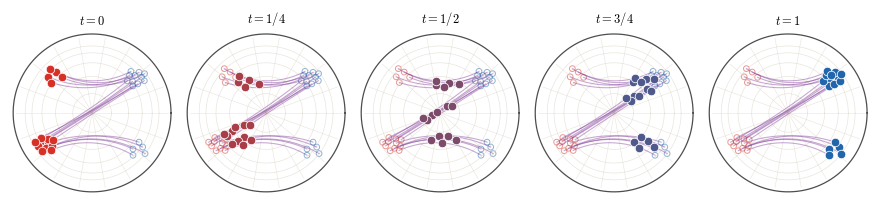

wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/monge-hyperbolic-mccann-interpolation/evolution.pdf
thumbnail /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/monge-hyperbolic-mccann-interpolation.png


In [5]:
def draw_poincare_disk(ax):
    """Draw a compact reference grid for the Poincare disk.

    Args:
        ax: Matplotlib axes receiving the disk geometry.

    Returns:
        None. The axes are modified in place.
    """
    angles = np.linspace(0.0, 2.0 * np.pi, 500)
    # Equal increments in hyperbolic distance from the origin correspond to
    # nonuniform Euclidean radii r = tanh(R / 2) in disk coordinates.
    intrinsic_radii = np.linspace(0.5, 2.5, 5)
    for euclidean_radius in np.tanh(intrinsic_radii / 2.0):
        ax.plot(
            euclidean_radius * np.cos(angles),
            euclidean_radius * np.sin(angles),
            color=LIGHT_GRAY,
            linewidth=0.45,
            alpha=0.62,
        )
    for angle in np.linspace(0.0, np.pi, 9, endpoint=False):
        direction = np.array([np.cos(angle), np.sin(angle)])
        endpoints = np.vstack([-0.96 * direction, 0.96 * direction])
        ax.plot(
            endpoints[:, 0],
            endpoints[:, 1],
            color=LIGHT_GRAY,
            linewidth=0.42,
            alpha=0.56,
        )
    ax.plot(np.cos(angles), np.sin(angles), color=GRAY, linewidth=0.90)
    ax.set(xlim=(-1.04, 1.04), ylim=(-1.04, 1.04))
    ax.set_aspect("equal")
    ax.axis("off")


path_times = np.linspace(0.0, 1.0, 120)
transport_paths = hyperbolic_geodesic(source, matched_target, path_times)
time_titles = [r"$t=0$", r"$t=1/4$", r"$t=1/2$", r"$t=3/4$", r"$t=1$"]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(11.1, 2.18),
    gridspec_kw={"wspace": 0.06},
)
for ax, time, points, title in zip(axes, plot_times, interpolated, time_titles):
    draw_poincare_disk(ax)
    for atom_path in np.swapaxes(transport_paths, 0, 1):
        ax.plot(
            atom_path[:, 0],
            atom_path[:, 1],
            color=VIOLET,
            linewidth=0.78,
            alpha=0.42,
        )
    ax.scatter(
        source[:, 0],
        source[:, 1],
        s=17,
        facecolors="none",
        edgecolors=RED,
        linewidths=0.70,
        alpha=0.50,
    )
    ax.scatter(
        target[:, 0],
        target[:, 1],
        s=17,
        facecolors="none",
        edgecolors=BLUE,
        linewidths=0.70,
        alpha=0.50,
    )
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=38,
        color=interp_color(time),
        edgecolors="white",
        linewidths=0.55,
        zorder=4,
    )
    ax.text(
        0.5,
        1.02,
        title,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=9.0,
    )

save_pdf(fig, OUT / "evolution.pdf", pad_inches=0.025)
fig.savefig(
    THUMB_OUT / f"{NAME}.png",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)
plt.show()
print(f"wrote {OUT / 'evolution.pdf'}")
print(f"thumbnail {THUMB_OUT / f'{NAME}.png'}")